# RAG Evaluation Analysis Notebook

This notebook loads `rag_eval_results.jsonl` produced by `app/eval_rag.py`,
builds per-category summaries, and renders **box plots per category** for each metric.

## What you'll get
- A tidy DataFrame of all evaluation records
- Summary stats per category
- Box plots per category for each metric
- Optional bar charts of mean values per category

## Metrics (from eval script)
- `qa_cosine`: alignment between question and answer embeddings (higher = better)
- `q_ctx_cosine`: alignment between question and retrieved context (higher = better)
- `a_ctx_cosine`: alignment between answer and retrieved context (higher = better)
- `jaccard_q_ctx`: lexical overlap between question and context (higher typically better)
- `jaccard_a_ctx`: lexical overlap between answer and context (moderate is OK; very low may indicate hallucination)
- `rougeL_recall_a_ctx`: ROUGE-L recall of answer vs context (higher = better grounding)
- `answer_novelty_vs_ctx`: fraction of answer tokens absent from context (lower = better grounding)
- `response_length`, `within_char_cap`: response control metrics

## Interpretation cheat sheet
- **Grounding** → prioritize `a_ctx_cosine`, `rougeL_recall_a_ctx`, *low* `answer_novelty_vs_ctx`
- **Retrieval quality** → `q_ctx_cosine`, `jaccard_q_ctx`
- **Answer relevance** → `qa_cosine`, `jaccard_a_ctx`
- **Brevity control** → `within_char_cap` and `response_length`


In [1]:
# # Fallback display helper for local Jupyter
# try:
#     from caas_jupyter_tools import display_dataframe_to_user  # not available locally
# except ImportError:
#     from IPython.display import display

#     def display_dataframe_to_user(name: str, dataframe):
#         # simple local replacement
#         try:
#             print(f"== {name} ==")
#         except Exception:
#             pass
#         display(dataframe)


In [2]:
from IPython.display import display

In [3]:
# ----- Setup -----
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
# from caas_jupyter_tools import display_dataframe_to_user



# Path to your JSONL results (edit if needed)
RESULTS_PATH = Path('rag_eval_results.jsonl')

# Metrics to analyze
METRICS = [
    'qa_cosine', 'q_ctx_cosine', 'a_ctx_cosine',
    'jaccard_q_ctx', 'jaccard_a_ctx',
    'rougeL_recall_a_ctx', 'answer_novelty_vs_ctx'
]

assert RESULTS_PATH.exists(), f"Results file not found: {RESULTS_PATH}"

records = []
summary = None
with RESULTS_PATH.open('r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        obj = json.loads(line)
        if 'summary' in obj:
            summary = obj['summary']
            continue
        records.append(obj)

df = pd.json_normalize(records)
print(f"Loaded {len(df)} records.")
if summary is not None:
    print('Run summary:', summary)
    
print('RAG Eval Records')
display(df)
# display_dataframe_to_user('', df)
df.head()

Loaded 60 records.
Run summary: {'n': 60, 'avg_qa_cosine': 0.4378, 'avg_q_ctx_cosine': 0.3628, 'avg_a_ctx_cosine': 0.5219, 'avg_jaccard_q_ctx': 0.0119, 'avg_jaccard_a_ctx': 0.0697, 'avg_rougeL_recall_a_ctx': 0.8472, 'avg_answer_novelty': 0.151, 'pct_within_char_cap': 100.0, 'avg_response_length': 105.0}
RAG Eval Records


,id,category,query,answer,response_length,within_char_cap,sources,retrieved_sources,context,metrics.qa_cosine,metrics.q_ctx_cosine,metrics.a_ctx_cosine,metrics.jaccard_q_ctx,metrics.jaccard_a_ctx,metrics.rougeL_recall_a_ctx,metrics.answer_novelty_vs_ctx
0,A1,fact_check,What is the recommended age to start complemen...,a,1,True,[https://www.who.int/news-room/fact-sheets/det...,[https://www.who.int/news-room/fact-sheets/det...,Related\nGlobal Strategy for Infant and Young ...,-0.007307,0.264040,0.013488,0.016667,0.005747,1.000000,0.000000
1,A2,fact_check,How long should exclusive breastfeeding continue?,a few years,11,True,[https://www.who.int/news-room/fact-sheets/det...,[https://www.who.int/news-room/fact-sheets/det...,Related\nGlobal Strategy for Infant and Young ...,0.236783,0.533804,0.023380,0.009950,0.015228,1.000000,0.000000
2,A3,fact_check,When should breastfeeding begin after birth?,4 August 2025 Breastfeeding in Indonesia on th...,130,True,[https://www.who.int/news-room/fact-sheets/det...,[https://www.who.int/news-room/fact-sheets/det...,Related\nGlobal Strategy for Infant and Young ...,0.441865,0.427379,0.713858,0.005587,0.108571,0.954545,0.045455
3,A4,fact_check,Until what age should breastfeeding continue a...,2 years of age or beyond,24,True,[https://www.who.int/news-room/fact-sheets/det...,[https://www.who.int/news-room/fact-sheets/det...,Related\nGlobal Strategy for Infant and Young ...,0.398183,0.631845,0.171581,0.025641,0.026042,0.833333,0.166667
4,A5,fact_check,Should infants be given water in the first 6 m...,"Breastfeeding in Indonesia on the rise, but mo...",137,True,[https://www.who.int/news-room/fact-sheets/det...,[https://www.who.int/news-room/fact-sheets/det...,Related\nGlobal Strategy for Infant and Young ...,0.284887,0.274041,0.795477,0.016575,0.114286,0.952381,0.047619
5,A6,fact_check,How often should infants be breastfed (on dema...,"Continue frequent, on-demand breastfeeding unt...",139,True,[https://www.who.int/news-room/fact-sheets/det...,[https://www.who.int/news-room/fact-sheets/det...,Related\nGlobal Strategy for Infant and Young ...,0.588084,0.493569,0.659679,0.010000,0.088083,0.894737,0.105263
6,A7,fact_check,Does WHO advise avoiding bottles and pacifiers...,More on breastfeedingMore about infant nutriti...,135,True,[https://www.who.int/news-room/fact-sheets/det...,[https://www.who.int/news-room/fact-sheets/det...,Related\nGlobal Strategy for Infant and Young ...,0.499977,0.378424,0.750799,0.016667,0.080000,0.875000,0.062500
7,A8,fact_check,Which organization recommends exclusive breast...,"World Breastfeeding Week, countries urged to i...",135,True,[https://www.who.int/news-room/fact-sheets/det...,[https://www.who.int/news-room/fact-sheets/det...,Related\nGlobal Strategy for Infant and Young ...,0.665661,0.649702,0.724771,0.020513,0.083333,0.947368,0.052632
8,A9,fact_check,Does WHO recommend continued breastfeeding up ...,Guiding principles for appropriate complementa...,136,True,[https://www.who.int/news-room/fact-sheets/det...,[https://www.who.int/news-room/fact-sheets/det...,Related\nGlobal Strategy for Infant and Young ...,0.700881,0.579421,0.691075,0.029703,0.080808,0.941176,0.058824
9,A10,fact_check,Does exclusive breastfeeding include no water ...,exclusive and continued breastfeeding can be i...,119,True,[https://www.who.int/news-room/fact-sheets/det...,[https://www.who.int/news-room/fact-sheets/det...,Related\nGlobal Strategy for Infant and Young ...,0.524029,0.410669,0.569232,0.016760,0.091954,1.000000,0.000000


,id,category,query,answer,response_length,within_char_cap,sources,retrieved_sources,context,metrics.qa_cosine,metrics.q_ctx_cosine,metrics.a_ctx_cosine,metrics.jaccard_q_ctx,metrics.jaccard_a_ctx,metrics.rougeL_recall_a_ctx,metrics.answer_novelty_vs_ctx
0,A1,fact_check,What is the recommended age to start complemen...,a,1,True,[https://www.who.int/news-room/fact-sheets/det...,[https://www.who.int/news-room/fact-sheets/det...,Related\nGlobal Strategy for Infant and Young ...,-0.007307,0.264040,0.013488,0.016667,0.005747,1.000000,0.000000
1,A2,fact_check,How long should exclusive breastfeeding continue?,a few years,11,True,[https://www.who.int/news-room/fact-sheets/det...,[https://www.who.int/news-room/fact-sheets/det...,Related\nGlobal Strategy for Infant and Young ...,0.236783,0.533804,0.023380,0.009950,0.015228,1.000000,0.000000
2,A3,fact_check,When should breastfeeding begin after birth?,4 August 2025 Breastfeeding in Indonesia on th...,130,True,[https://www.who.int/news-room/fact-sheets/det...,[https://www.who.int/news-room/fact-sheets/det...,Related\nGlobal Strategy for Infant and Young ...,0.441865,0.427379,0.713858,0.005587,0.108571,0.954545,0.045455
3,A4,fact_check,Until what age should breastfeeding continue a...,2 years of age or beyond,24,True,[https://www.who.int/news-room/fact-sheets/det...,[https://www.who.int/news-room/fact-sheets/det...,Related\nGlobal Strategy for Infant and Young ...,0.398183,0.631845,0.171581,0.025641,0.026042,0.833333,0.166667
4,A5,fact_check,Should infants be given water in the first 6 m...,"Breastfeeding in Indonesia on the rise, but mo...",137,True,[https://www.who.int/news-room/fact-sheets/det...,[https://www.who.int/news-room/fact-sheets/det...,Related\nGlobal Strategy for Infant and Young ...,0.284887,0.274041,0.795477,0.016575,0.114286,0.952381,0.047619


In [4]:
# ----- Basic cleanliness checks -----
required_cols = ['category', 'query', 'answer', 'metrics.qa_cosine']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in results: {missing}")

# Short aliases for metric columns
for m in ['qa_cosine','q_ctx_cosine','a_ctx_cosine','jaccard_q_ctx','jaccard_a_ctx','rougeL_recall_a_ctx','answer_novelty_vs_ctx']:
    col = f'metrics.{m}'
    if col in df.columns:
        df[m] = df[col]
    else:
        df[m] = None

# Make sure 'category' exists
if 'category' not in df.columns:
    df['category'] = 'unknown'

df_metrics = df[['id','category','response_length','within_char_cap'] + METRICS].copy()
# display_dataframe_to_user('RAG Eval Metrics (wide)', df_metrics)
print('RAG Eval Metrics (wide)')
display(df_metrics)
df_metrics.head()

RAG Eval Metrics (wide)


,id,category,response_length,within_char_cap,qa_cosine,q_ctx_cosine,a_ctx_cosine,jaccard_q_ctx,jaccard_a_ctx,rougeL_recall_a_ctx,answer_novelty_vs_ctx
0,A1,fact_check,1,True,-0.007307,0.264040,0.013488,0.016667,0.005747,1.000000,0.000000
1,A2,fact_check,11,True,0.236783,0.533804,0.023380,0.009950,0.015228,1.000000,0.000000
2,A3,fact_check,130,True,0.441865,0.427379,0.713858,0.005587,0.108571,0.954545,0.045455
3,A4,fact_check,24,True,0.398183,0.631845,0.171581,0.025641,0.026042,0.833333,0.166667
4,A5,fact_check,137,True,0.284887,0.274041,0.795477,0.016575,0.114286,0.952381,0.047619
5,A6,fact_check,139,True,0.588084,0.493569,0.659679,0.010000,0.088083,0.894737,0.105263
6,A7,fact_check,135,True,0.499977,0.378424,0.750799,0.016667,0.080000,0.875000,0.062500
7,A8,fact_check,135,True,0.665661,0.649702,0.724771,0.020513,0.083333,0.947368,0.052632
8,A9,fact_check,136,True,0.700881,0.579421,0.691075,0.029703,0.080808,0.941176,0.058824
9,A10,fact_check,119,True,0.524029,0.410669,0.569232,0.016760,0.091954,1.000000,0.000000


,id,category,response_length,within_char_cap,qa_cosine,q_ctx_cosine,a_ctx_cosine,jaccard_q_ctx,jaccard_a_ctx,rougeL_recall_a_ctx,answer_novelty_vs_ctx
0,A1,fact_check,1,True,-0.007307,0.264040,0.013488,0.016667,0.005747,1.000000,0.000000
1,A2,fact_check,11,True,0.236783,0.533804,0.023380,0.009950,0.015228,1.000000,0.000000
2,A3,fact_check,130,True,0.441865,0.427379,0.713858,0.005587,0.108571,0.954545,0.045455
3,A4,fact_check,24,True,0.398183,0.631845,0.171581,0.025641,0.026042,0.833333,0.166667
4,A5,fact_check,137,True,0.284887,0.274041,0.795477,0.016575,0.114286,0.952381,0.047619


In [5]:
# ----- Summary by category -----
summary_cols = ['response_length'] + METRICS
summary_by_cat = df_metrics.groupby('category')[summary_cols].agg(['count','mean','std']).round(4)
# from caas_jupyter_tools import display_dataframe_to_user
# display_dataframe_to_user('Summary by Category (count/mean/std)', summary_by_cat)
print('Summary by Category (count/mean/std)')
display(summary_by_cat)
summary_by_cat

Summary by Category (count/mean/std)


response_length                 qa_cosine          \
                                   count   mean      std     count    mean   
category                                                                     
fact_check                            10   96.7  58.9596        10  0.4333   
multilingual                          10  114.3  46.3682        10  0.1716   
noisy_grammar                         10  106.7  49.4032        10  0.4068   
on_topic_outside_context              10  111.2  32.8965        10  0.5165   
semantic_paraphrase                   10   80.2  59.3180        10  0.4897   
summarization                         10  120.6  28.9759        10  0.6088   

                                 q_ctx_cosine                 a_ctx_cosine  \
                             std        count    mean     std        count   
category                                                                     
fact_check                0.2156           10  0.4643  0.1372           10   
multilingual              0.3436           10  0.1127  0.1507           10   
noisy_grammar             0.2483           10  0.4680  0.1117           10   
on_topic_outside_context  0.3119           10  0.2635  0.1248           10   
semantic_paraphrase       0.3437           10  0.4190  0.1290           10   
summarization             0.1386           10  0.4494  0.1558           10   

                          ... jaccard_q_ctx jaccard_a_ctx                  \
                          ...           std         count    mean     std   
category                  ...                                               
fact_check                ...        0.0073            10  0.0694  0.0390   
multilingual              ...        0.0048            10  0.0683  0.0383   
noisy_grammar             ...        0.0076            10  0.0816  0.0376   
on_topic_outside_context  ...        0.0066            10  0.0712  0.0385   
semantic_paraphrase       ...        0.0087            10  0.0528  0.0463   
summarization             ...        0.0049            10  0.0748  0.0248   

                         rougeL_recall_a_ctx                  \
                                       count    mean     std   
category                                                       
fact_check                                10  0.9399  0.0566   
multilingual                              10  0.7478  0.3943   
noisy_grammar                             10  0.9143  0.0966   
on_topic_outside_context                  10  0.7883  0.2949   
semantic_paraphrase                       10  0.8024  0.3616   
summarization                             10  0.8907  0.1736   

                         answer_novelty_vs_ctx                  
                                         count    mean     std  
category                                                        
fact_check                                  10  0.0539  0.0519  
multilingual                                10  0.2477  0.3966  
noisy_grammar                               10  0.0857  0.0966  
on_topic_outside_context                    10  0.2117  0.2949  
semantic_paraphrase                         10  0.1976  0.3616  
summarization                               10  0.1093  0.1736  

[6 rows x 24 columns]

response_length                 qa_cosine          \
                                   count   mean      std     count    mean   
category                                                                     
fact_check                            10   96.7  58.9596        10  0.4333   
multilingual                          10  114.3  46.3682        10  0.1716   
noisy_grammar                         10  106.7  49.4032        10  0.4068   
on_topic_outside_context              10  111.2  32.8965        10  0.5165   
semantic_paraphrase                   10   80.2  59.3180        10  0.4897   
summarization                         10  120.6  28.9759        10  0.6088   

                                 q_ctx_cosine                 a_ctx_cosine  \
                             std        count    mean     std        count   
category                                                                     
fact_check                0.2156           10  0.4643  0.1372           10   
multilingual              0.3436           10  0.1127  0.1507           10   
noisy_grammar             0.2483           10  0.4680  0.1117           10   
on_topic_outside_context  0.3119           10  0.2635  0.1248           10   
semantic_paraphrase       0.3437           10  0.4190  0.1290           10   
summarization             0.1386           10  0.4494  0.1558           10   

                          ... jaccard_q_ctx jaccard_a_ctx                  \
                          ...           std         count    mean     std   
category                  ...                                               
fact_check                ...        0.0073            10  0.0694  0.0390   
multilingual              ...        0.0048            10  0.0683  0.0383   
noisy_grammar             ...        0.0076            10  0.0816  0.0376   
on_topic_outside_context  ...        0.0066            10  0.0712  0.0385   
semantic_paraphrase       ...        0.0087            10  0.0528  0.0463   
summarization             ...        0.0049            10  0.0748  0.0248   

                         rougeL_recall_a_ctx                  \
                                       count    mean     std   
category                                                       
fact_check                                10  0.9399  0.0566   
multilingual                              10  0.7478  0.3943   
noisy_grammar                             10  0.9143  0.0966   
on_topic_outside_context                  10  0.7883  0.2949   
semantic_paraphrase                       10  0.8024  0.3616   
summarization                             10  0.8907  0.1736   

                         answer_novelty_vs_ctx                  
                                         count    mean     std  
category                                                        
fact_check                                  10  0.0539  0.0519  
multilingual                                10  0.2477  0.3966  
noisy_grammar                               10  0.0857  0.0966  
on_topic_outside_context                    10  0.2117  0.2949  
semantic_paraphrase                         10  0.1976  0.3616  
summarization                               10  0.1093  0.1736  

[6 rows x 24 columns]

## Box plots per metric (by category)
Each plot shows the distribution of a metric across categories. This helps identify variance, outliers, and skew.


C:\Users\User\AppData\Local\Temp\ipykernel_26704\1054725135.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=cats, showfliers=True)


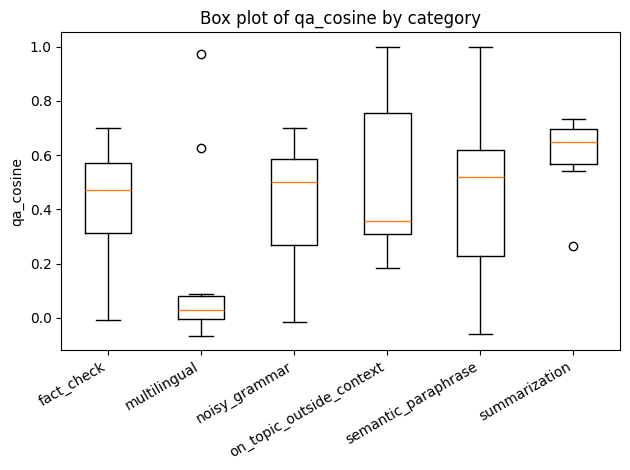

C:\Users\User\AppData\Local\Temp\ipykernel_26704\1054725135.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=cats, showfliers=True)


Saved plots\box_qa_cosine.png


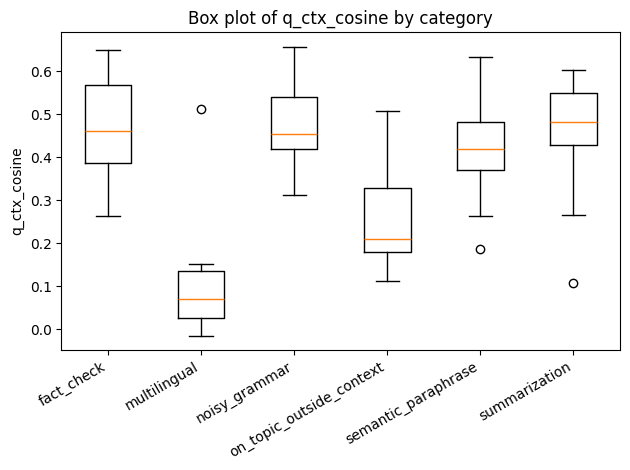

Saved plots\box_q_ctx_cosine.png


C:\Users\User\AppData\Local\Temp\ipykernel_26704\1054725135.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=cats, showfliers=True)


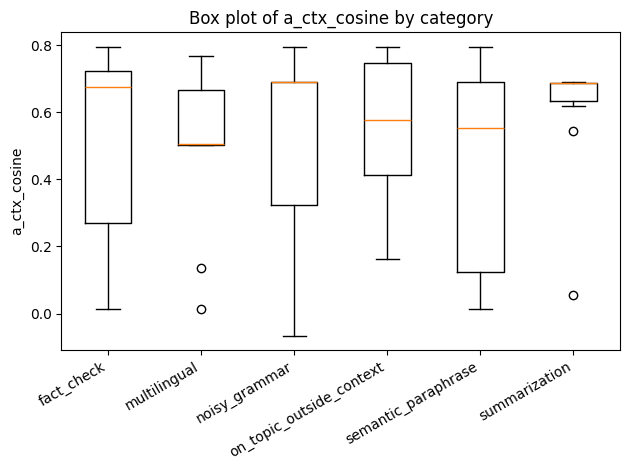

Saved plots\box_a_ctx_cosine.png


C:\Users\User\AppData\Local\Temp\ipykernel_26704\1054725135.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=cats, showfliers=True)


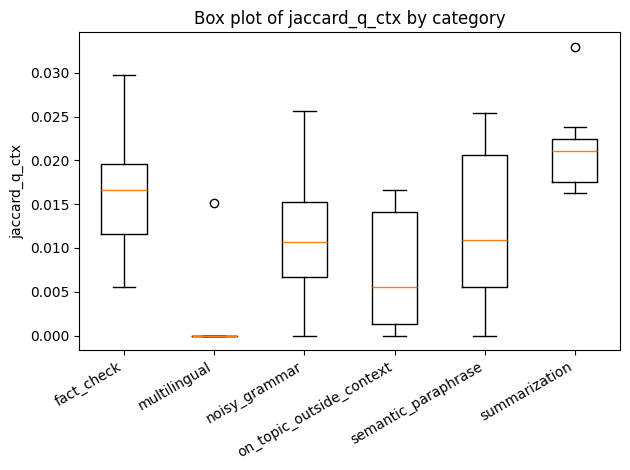

Saved plots\box_jaccard_q_ctx.png


C:\Users\User\AppData\Local\Temp\ipykernel_26704\1054725135.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=cats, showfliers=True)


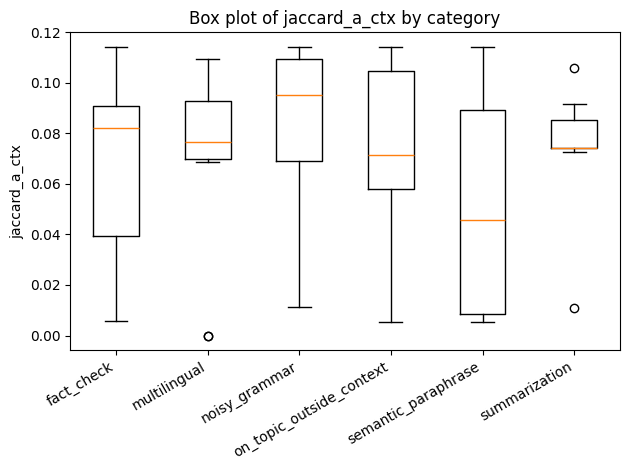

Saved plots\box_jaccard_a_ctx.png


C:\Users\User\AppData\Local\Temp\ipykernel_26704\1054725135.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=cats, showfliers=True)


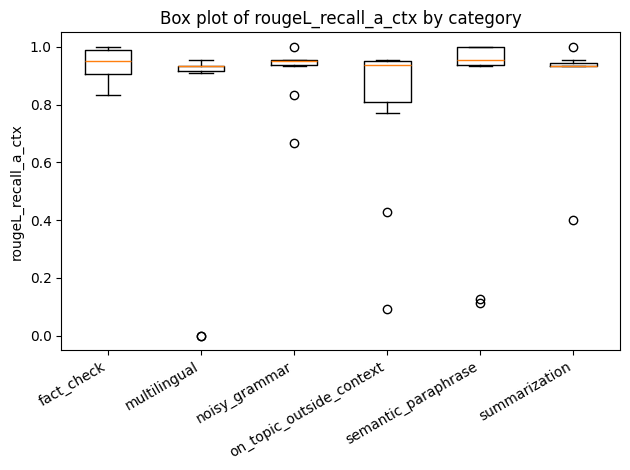

Saved plots\box_rougeL_recall_a_ctx.png


C:\Users\User\AppData\Local\Temp\ipykernel_26704\1054725135.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=cats, showfliers=True)


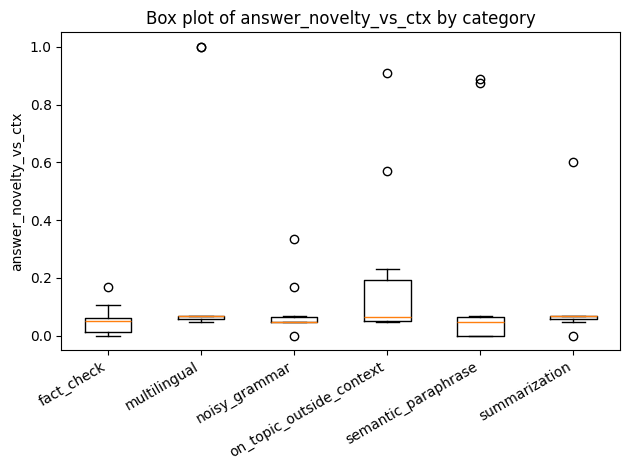

Saved plots\box_answer_novelty_vs_ctx.png


In [6]:
# ----- Box plots for each metric -----
import os
plots_dir = Path('plots')
plots_dir.mkdir(exist_ok=True)

cats = list(df_metrics['category'].dropna().unique())
cats.sort()
for m in METRICS:
    plt.figure()
    data = [df_metrics[df_metrics['category']==c][m].dropna().values for c in cats]
    plt.boxplot(data, labels=cats, showfliers=True)
    plt.title(f'Box plot of {m} by category')
    plt.ylabel(m)
    plt.xticks(rotation=30, ha='right')
    out_path = plots_dir / f'box_{m}.png'
    plt.tight_layout()
    plt.savefig(out_path)
    plt.show()
    print(f'Saved {out_path}')


## Median comparison bar charts (by category)
These complement box plots by summarizing central tendency per category.


Metric Medians by Category


,category,qa_cosine,q_ctx_cosine,a_ctx_cosine,jaccard_q_ctx,jaccard_a_ctx,rougeL_recall_a_ctx,answer_novelty_vs_ctx
0,fact_check,0.470921,0.460474,0.675377,0.016667,0.082071,0.949875,0.050125
1,multilingual,0.029836,0.071564,0.507022,0.000000,0.076777,0.933333,0.066667
2,noisy_grammar,0.499309,0.453984,0.689089,0.010658,0.095092,0.952381,0.047619
3,on_topic_outside_context,0.355456,0.211248,0.577735,0.005540,0.071429,0.935417,0.064583
4,semantic_paraphrase,0.519181,0.419852,0.554716,0.010959,0.045764,0.953463,0.046537
5,summarization,0.649835,0.481628,0.686081,0.021074,0.074286,0.933333,0.066667


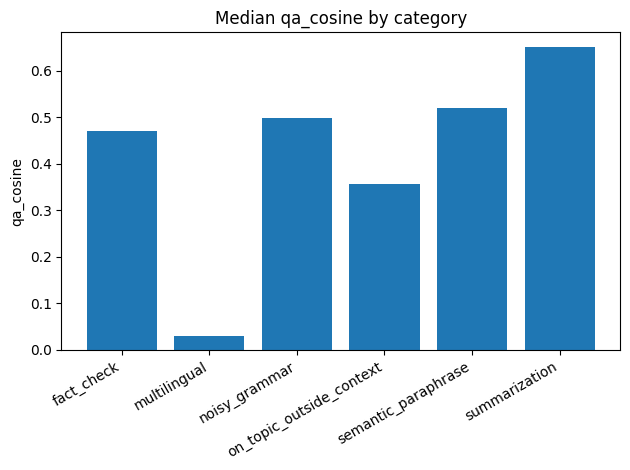

Saved plots\median_qa_cosine.png


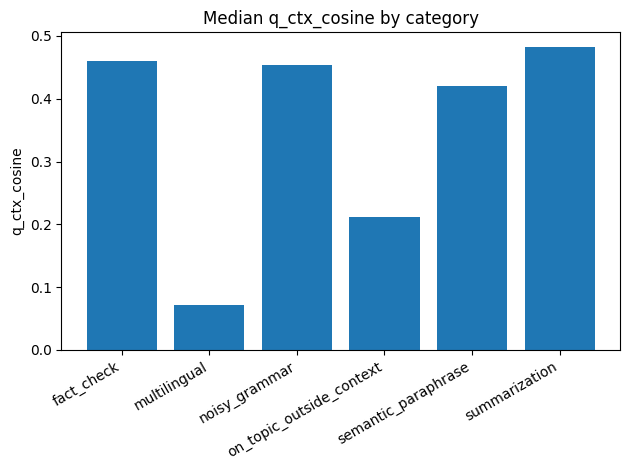

Saved plots\median_q_ctx_cosine.png


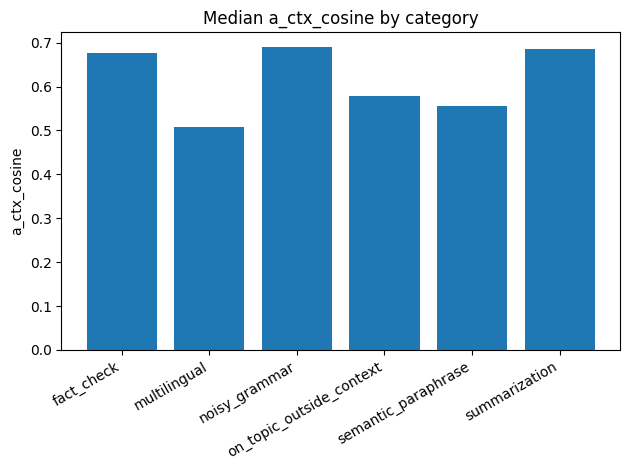

Saved plots\median_a_ctx_cosine.png


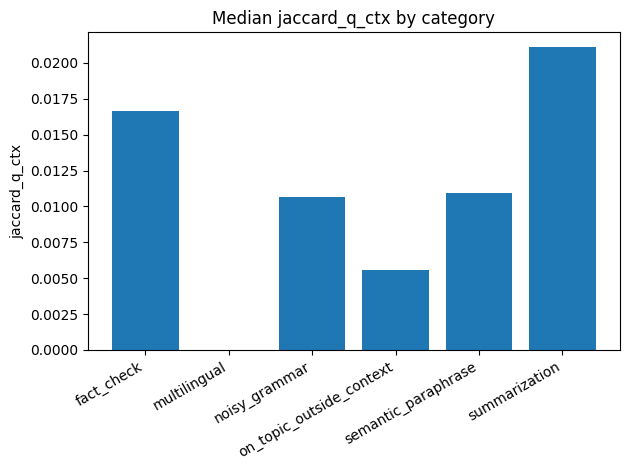

Saved plots\median_jaccard_q_ctx.png


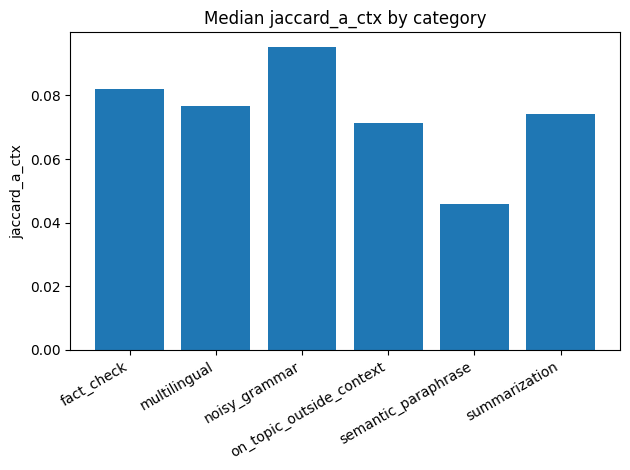

Saved plots\median_jaccard_a_ctx.png


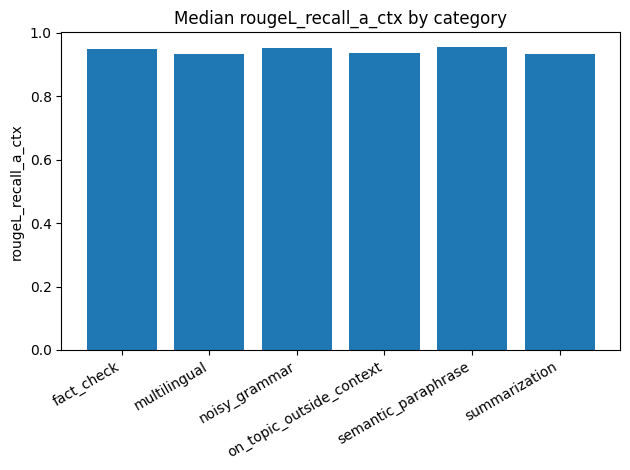

Saved plots\median_rougeL_recall_a_ctx.png


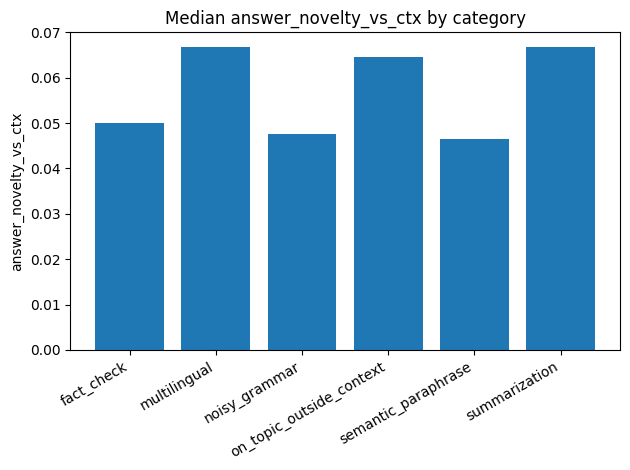

Saved plots\median_answer_novelty_vs_ctx.png


In [7]:
# ----- Median bar charts for each metric -----
medians = df_metrics.groupby('category')[METRICS].median().reset_index()

print('Metric Medians by Category')
display(medians)

for m in METRICS:
    plt.figure()
    x = medians['category']
    y = medians[m]
    plt.bar(x, y)
    plt.title(f'Median {m} by category')
    plt.ylabel(m)
    plt.xticks(rotation=30, ha='right')
    out_path = Path('plots') / f'median_{m}.png'
    plt.tight_layout()
    plt.savefig(out_path)
    plt.show()
    print(f'Saved {out_path}')


## Mean comparison bar charts (by category)
These complement box plots by summarizing central tendency per category.


Metric Means by Category


,category,qa_cosine,q_ctx_cosine,a_ctx_cosine,jaccard_q_ctx,jaccard_a_ctx,rougeL_recall_a_ctx,answer_novelty_vs_ctx
0,fact_check,0.433304,0.464289,0.511334,0.016806,0.069405,0.939854,0.053896
1,multilingual,0.171591,0.112729,0.494715,0.001515,0.068317,0.747767,0.247687
2,noisy_grammar,0.406802,0.467978,0.530381,0.011835,0.081598,0.914291,0.085709
3,on_topic_outside_context,0.516526,0.263511,0.548145,0.007469,0.071241,0.788311,0.211689
4,semantic_paraphrase,0.489747,0.418970,0.444565,0.012411,0.052759,0.802374,0.197626
5,summarization,0.608810,0.449422,0.602067,0.021298,0.074788,0.890683,0.109317


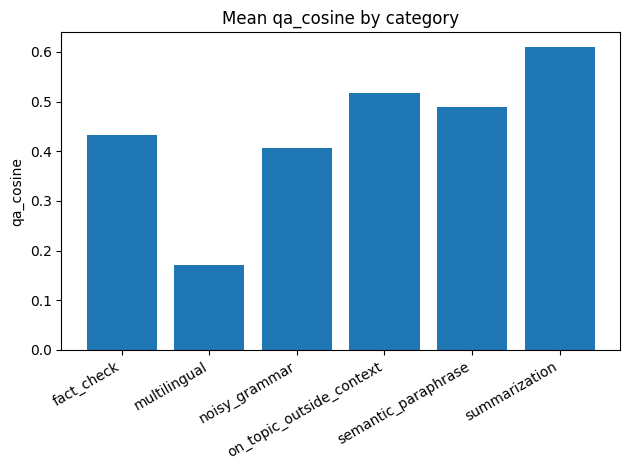

Saved plots\mean_qa_cosine.png


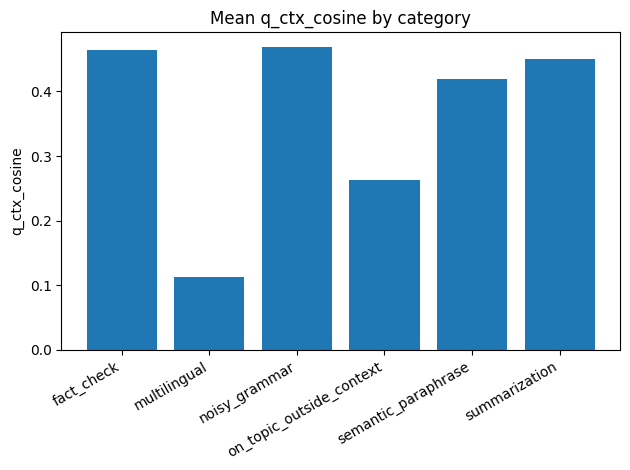

Saved plots\mean_q_ctx_cosine.png


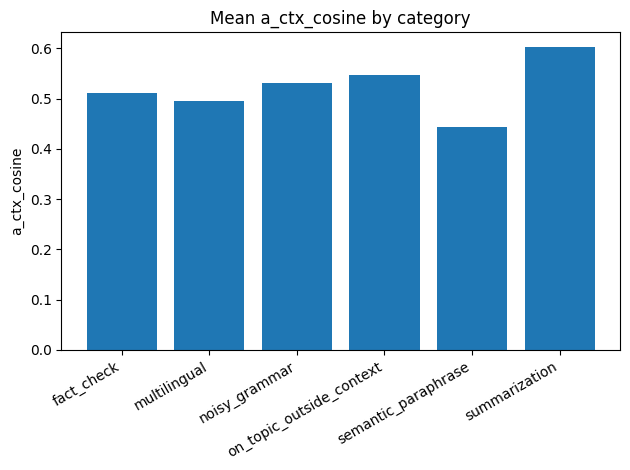

Saved plots\mean_a_ctx_cosine.png


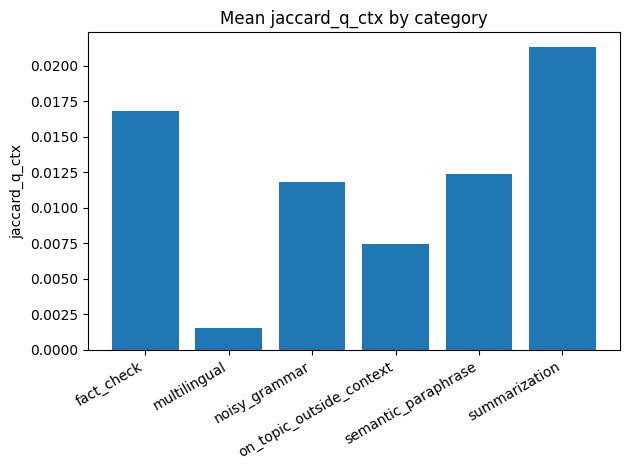

Saved plots\mean_jaccard_q_ctx.png


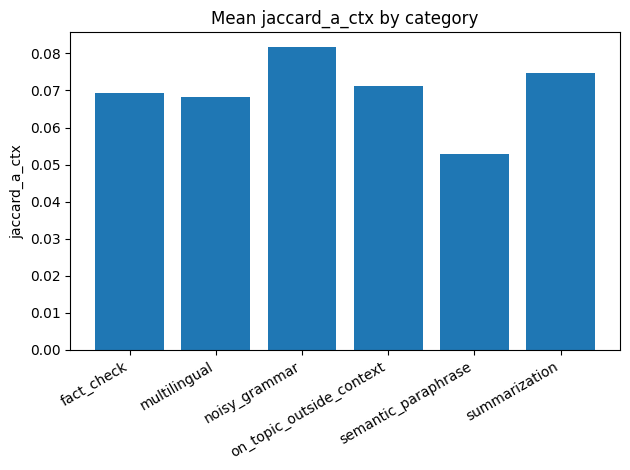

Saved plots\mean_jaccard_a_ctx.png


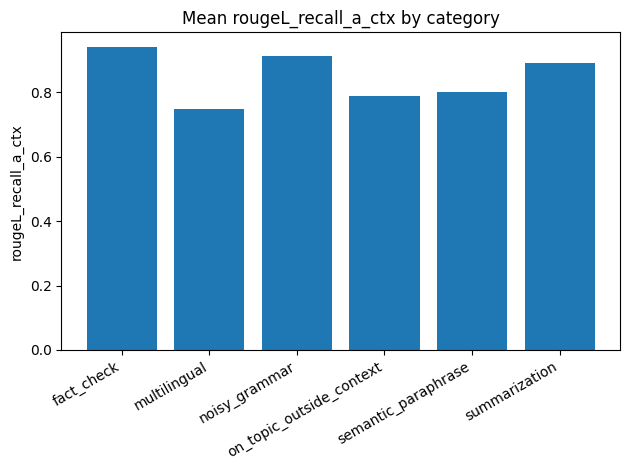

Saved plots\mean_rougeL_recall_a_ctx.png


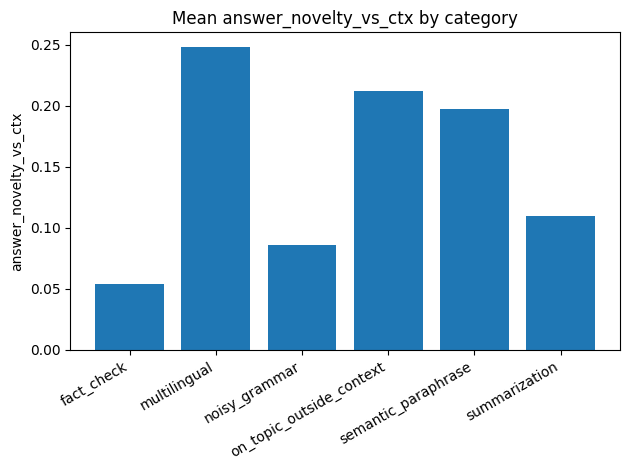

Saved plots\mean_answer_novelty_vs_ctx.png


In [8]:
# ----- Mean bar charts for each metric -----
means = df_metrics.groupby('category')[METRICS].mean().reset_index()
# from caas_jupyter_tools import display_dataframe_to_user
# display_dataframe_to_user('Metric Means by Category', means)

print('Metric Means by Category')
display(means)

for m in METRICS:
    plt.figure()
    x = means['category']
    y = means[m]
    plt.bar(x, y)
    plt.title(f'Mean {m} by category')
    plt.ylabel(m)
    plt.xticks(rotation=30, ha='right')
    out_path = Path('plots') / f'mean_{m}.png'
    plt.tight_layout()
    plt.savefig(out_path)
    plt.show()
    print(f'Saved {out_path}')


# Means and medians plotted as group bar plot

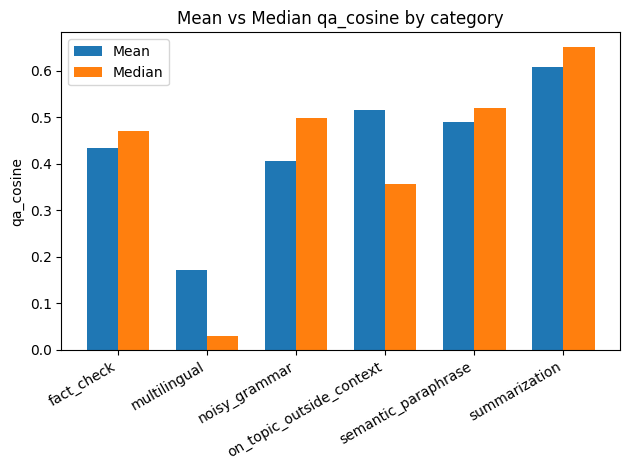

Saved plots\grouped_mean_median_qa_cosine.png


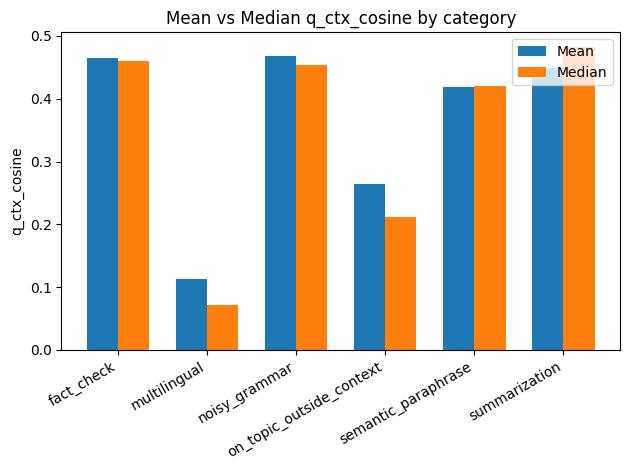

Saved plots\grouped_mean_median_q_ctx_cosine.png


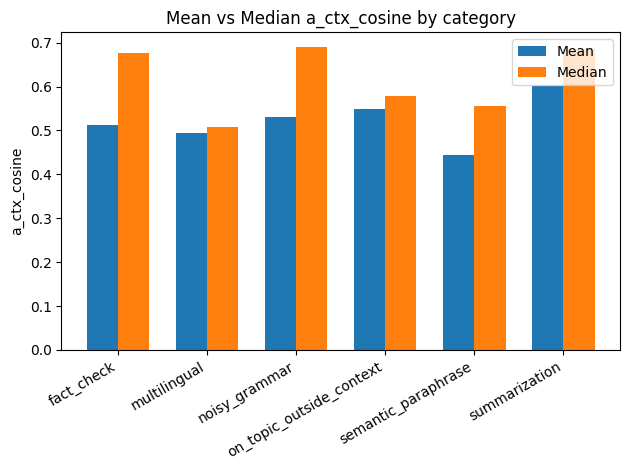

Saved plots\grouped_mean_median_a_ctx_cosine.png


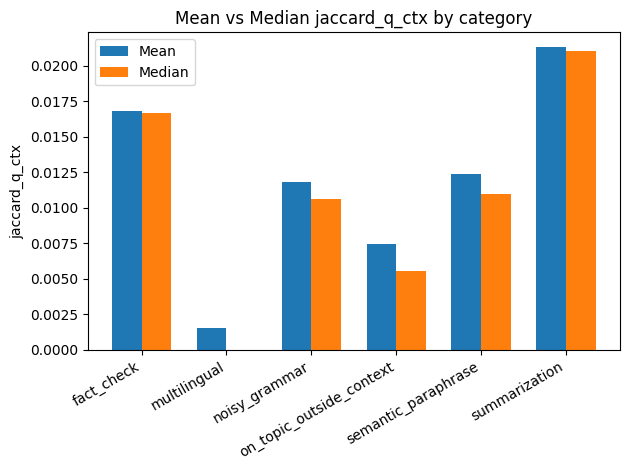

Saved plots\grouped_mean_median_jaccard_q_ctx.png


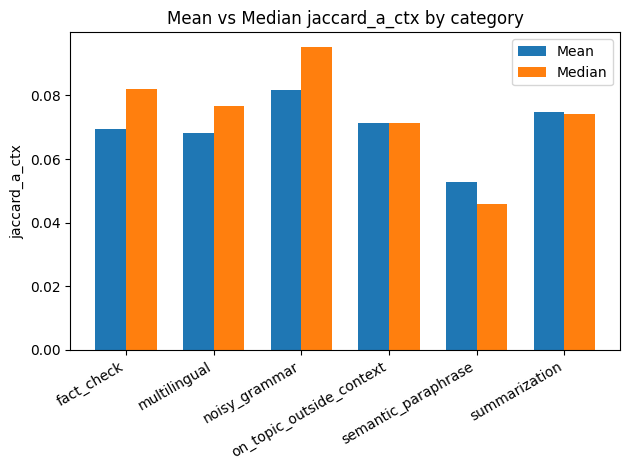

Saved plots\grouped_mean_median_jaccard_a_ctx.png


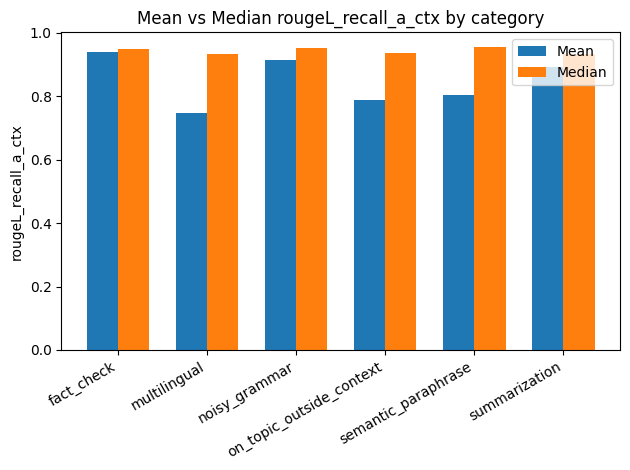

Saved plots\grouped_mean_median_rougeL_recall_a_ctx.png


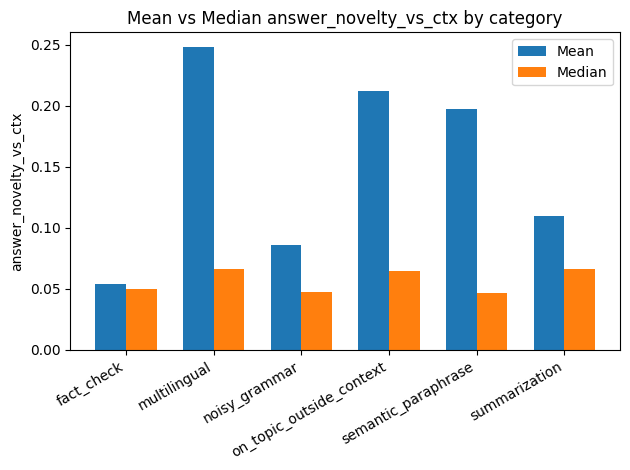

Saved plots\grouped_mean_median_answer_novelty_vs_ctx.png


In [9]:
# ----- Grouped bar: Mean vs Median per metric (by category) -----
import numpy as np
from pathlib import Path

# Ensure we have fresh means/medians aligned to the same category order
cats = sorted(df_metrics['category'].dropna().unique())
means = df_metrics.groupby('category')[METRICS].mean().reindex(cats).reset_index()
medians = df_metrics.groupby('category')[METRICS].median().reindex(cats).reset_index()

plots_dir = Path('plots')
plots_dir.mkdir(exist_ok=True)

for m in METRICS:
    fig, ax = plt.subplots()

    x = np.arange(len(cats))
    width = 0.35  # bar width

    ax.bar(x - width/2, means[m].values, width=width, label='Mean')
    ax.bar(x + width/2, medians[m].values, width=width, label='Median')

    ax.set_title(f'Mean vs Median {m} by category')
    ax.set_ylabel(m)
    ax.set_xticks(x)
    ax.set_xticklabels(cats, rotation=30, ha='right')
    ax.legend()

    out_path = plots_dir / f'grouped_mean_median_{m}.png'
    fig.tight_layout()
    fig.savefig(out_path)
    plt.show()
    print(f"Saved {out_path}")


## Interpreting the results
- **`a_ctx_cosine`**: If consistently high across categories, answers are well grounded in retrieved context. If low for a category (e.g., multilingual), consider improving multilingual retrieval/translation.
- **`q_ctx_cosine`**: Indicates retriever is pulling relevant chunks. If low for noisy grammar or paraphrased queries, consider query normalization or better embeddings.
- **`qa_cosine`**: High suggests answers are relevant to the question. If this is high but `a_ctx_cosine` is low, answers may be relevant but not grounded → improve RAG grounding.
- **`rougeL_recall_a_ctx`**: High values (e.g., >0.7) mean the answer reuses content from context, a good proxy for grounding.
- **`answer_novelty_vs_ctx`**: Lower is better; if high, the model is adding content not present in context (risk of hallucination).
- **`jaccard_*`**: Helpful lexical sanity checks; very low `jaccard_a_ctx` plus low `a_ctx_cosine` is a red flag.
- **`response_length` & `within_char_cap`**: Ensure formatting constraints are met; if length is near the cap across the board, consider reducing `MAX_CHAR_LEN_RESP` or enforcing stricter brevity.

### What conclusions to draw
1. **Compare categories**: Identify which categories underperform (e.g., `multilingual`, `noisy_grammar`) and target improvements (translation layer, spelling correction, better retrieval).
2. **Retrieval vs. Generation**: If `q_ctx_cosine` is strong but `a_ctx_cosine` is weak, focus on the prompt to force grounding; if `q_ctx_cosine` is weak, focus on embeddings, chunking, or sources.
3. **Precision vs. Recall**: High `rougeL_recall_a_ctx` with low `qa_cosine` might indicate copying context without addressing the question; tune templates.
4. **Safety/Brevity**: Ensure `within_char_cap` is 100%. If not, tighten the post-processor or reduce `MAX_CHAR_LEN_RESP`.
